In [1]:
import os
import numpy as np
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import resample
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
import tensorflow as tf
import collections

print("✅ Imports OK")

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'


✅ Imports OK


In [2]:
def extract_mel(file_path, max_len=128, n_mels=128, sr=22050):
    try:
        y, sr = librosa.load(file_path, sr=sr, duration=5.0)
        mel = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=n_mels)
        mel_db = librosa.power_to_db(mel, ref=np.max)
        if mel_db.shape[1] < max_len:
            mel_db = np.pad(mel_db, ((0,0),(0, max_len - mel_db.shape[1])))
        else:
            mel_db = mel_db[:, :max_len]
        return mel_db
    except Exception as e:
        print(f"Erreur sur {file_path}: {e}")
        return None

print("✅ Fonction extract_mel prête")

✅ Fonction extract_mel prête


In [5]:
# Chemins SESA
screaming_path    = r"C:\Users\AHMED MOHATI\Documents\School\S2\ProgrammationMobile\Projet\V1\data\SESA\Screaming"
notscreaming_path = r"C:\Users\AHMED MOHATI\Documents\School\S2\ProgrammationMobile\Projet\V1\data\SESA\NotScreaming"

X, y_labels = [], []

# DANGER = cris
for f in os.listdir(screaming_path):
    if f.endswith('.wav') or f.endswith('.mp3'):
        mel = extract_mel(os.path.join(screaming_path, f))
        if mel is not None:
            X.append(mel)
            y_labels.append(1)

# NORMAL = pas de cris
for f in os.listdir(notscreaming_path):
    if f.endswith('.wav') or f.endswith('.mp3'):
        mel = extract_mel(os.path.join(notscreaming_path, f))
        if mel is not None:
            X.append(mel)
            y_labels.append(0)

X = np.array(X)
y_labels = np.array(y_labels)

print(f"✅ SESA chargé !")
print(f"🔴 DANGER  : {sum(y_labels == 1)}")
print(f"🟢 NORMAL  : {sum(y_labels == 0)}")
print(f"📊 Total   : {len(X)}")

✅ SESA chargé !
🔴 DANGER  : 862
🟢 NORMAL  : 2631
📊 Total   : 3493


In [7]:
# Chemins Violence dataset
violence_path     = r"C:\Users\AHMED MOHATI\Documents\School\S2\ProgrammationMobile\Projet\V2\data\VIOLENCE\violence"
nonviolence_path  = r"C:\Users\AHMED MOHATI\Documents\School\S2\ProgrammationMobile\Projet\V2\data\VIOLENCE\non-violence"

X_fight, X_noviolence = [], []

# FIGHT = sons de violence
for f in os.listdir(violence_path):
    if f.endswith('.wav') or f.endswith('.mp3'):
        mel = extract_mel(os.path.join(violence_path, f))
        if mel is not None:
            X_fight.append(mel)

# NON-VIOLENCE supplémentaire
for f in os.listdir(nonviolence_path):
    if f.endswith('.wav') or f.endswith('.mp3'):
        mel = extract_mel(os.path.join(nonviolence_path, f))
        if mel is not None:
            X_noviolence.append(mel)

print(f"✅ Violence dataset chargé !")
print(f"🟠 FIGHT       : {len(X_fight)}")
print(f"🟢 NON-VIOLENCE: {len(X_noviolence)}")

✅ Violence dataset chargé !
🟠 FIGHT       : 127
🟢 NON-VIOLENCE: 4


In [8]:
# Préparer les arrays avec dimension canal
X_input = X[..., np.newaxis]

X_normal = X_input[y_labels == 0]
X_danger = X_input[y_labels == 1]
X_fight_np = np.array(X_fight)[..., np.newaxis]
X_noviolence_np = np.array(X_noviolence)[..., np.newaxis]

print("=== Avant fusion ===")
print(f"🟢 NORMAL (SESA)        : {len(X_normal)}")
print(f"🔴 DANGER (SESA)        : {len(X_danger)}")
print(f"🟠 FIGHT (Violence)     : {len(X_fight_np)}")
print(f"🟢 NON-VIOLENCE (extra) : {len(X_noviolence_np)}")

# Enrichir DANGER avec fight
X_danger_enriched = np.vstack([X_danger, X_fight_np])

# Enrichir NORMAL avec non-violence
X_normal_enriched = np.vstack([X_normal, X_noviolence_np])

print(f"\n=== Après enrichissement ===")
print(f"🔴 DANGER enrichi : {len(X_danger_enriched)}")
print(f"🟢 NORMAL enrichi : {len(X_normal_enriched)}")

# Rééquilibrer
min_size = min(len(X_normal_enriched), len(X_danger_enriched))
print(f"📊 Taille cible   : {min_size}")

X_normal_balanced = resample(X_normal_enriched, n_samples=min_size, random_state=42)
X_danger_balanced = resample(X_danger_enriched, n_samples=min_size, random_state=42)

X_balanced_v2 = np.vstack([X_normal_balanced, X_danger_balanced])
y_balanced_v2 = np.array([0]*min_size + [1]*min_size)

print(f"\n=== Dataset final V2 ===")
print(f"🟢 NORMAL : {sum(y_balanced_v2 == 0)}")
print(f"🔴 DANGER : {sum(y_balanced_v2 == 1)}")
print(f"✅ Total  : {len(X_balanced_v2)}")

=== Avant fusion ===
🟢 NORMAL (SESA)        : 2631
🔴 DANGER (SESA)        : 862
🟠 FIGHT (Violence)     : 127
🟢 NON-VIOLENCE (extra) : 4

=== Après enrichissement ===
🔴 DANGER enrichi : 989
🟢 NORMAL enrichi : 2635
📊 Taille cible   : 989

=== Dataset final V2 ===
🟢 NORMAL : 989
🔴 DANGER : 989
✅ Total  : 1978


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced_v2, y_balanced_v2,
    test_size=0.2,
    random_state=42,
    stratify=y_balanced_v2
)

print(f"✅ Train : {len(X_train)}")
print(f"✅ Test  : {len(X_test)}")

model_v2 = models.Sequential([
    layers.Input(shape=(128, 128, 1)),
    layers.Conv2D(32, (3,3), activation='relu', padding='same',
                  kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.2),
    layers.Conv2D(64, (3,3), activation='relu', padding='same',
                  kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.2),
    layers.Conv2D(128, (3,3), activation='relu', padding='same',
                  kernel_regularizer=regularizers.l2(0.001)),
    layers.BatchNormalization(),
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.4),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

model_v2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', 'AUC']
)

callbacks = [
    EarlyStopping(patience=8, restore_best_weights=True, verbose=1),
    ModelCheckpoint("best_model_v2.keras", save_best_only=True, verbose=1),
    ReduceLROnPlateau(factor=0.5, patience=3, verbose=1)
]

history_v2 = model_v2.fit(
    X_train, y_train,
    epochs=50,
    batch_size=16,
    validation_data=(X_test, y_test),
    callbacks=callbacks
)

✅ Train : 1582
✅ Test  : 396



Epoch 1/50


99/99 [==============================] - ETA: 0s - loss: 0.8046 - accuracy: 0.5967 - auc: 0.6281
Epoch 1: val_loss improved from inf to 1.30901, saving model to best_model_v2.keras
99/99 [==============================] - 30s 259ms/step - loss: 0.8046 - accuracy: 0.5967 - auc: 0.6281 - val_loss: 1.3090 - val_accuracy: 0.5000 - val_auc: 0.6994 - lr: 0.0010
Epoch 2/50
99/99 [==============================] - ETA: 0s - loss: 0.7131 - accuracy: 0.6947 - auc: 0.7480
Epoch 2: val_loss improved from 1.30901 to 1.23497, saving model to best_model_v2.keras
99/99 [==============================] - 24s 244ms/step - loss: 0.7131 - accuracy: 0.6947 - auc: 0.7480 - val_loss: 1.2350 - val_accuracy: 0.5000 - val_auc: 0.7538 - lr: 0.0010
Epoch 3/50
99/99 [==============================] - ETA: 0s - loss: 0.6595 - accuracy: 0.7212 - auc: 0.7904
Epoch 3: val_loss improved from 1.23497 to 0.65347, saving model to best_model_v2.keras
99/99 [=====================

13/13 [==============================] - 2s 128ms/step
=== Résultats V2 ===
              precision    recall  f1-score   support

      NORMAL       0.81      0.86      0.84       198
      DANGER       0.85      0.80      0.83       198

    accuracy                           0.83       396
   macro avg       0.83      0.83      0.83       396
weighted avg       0.83      0.83      0.83       396



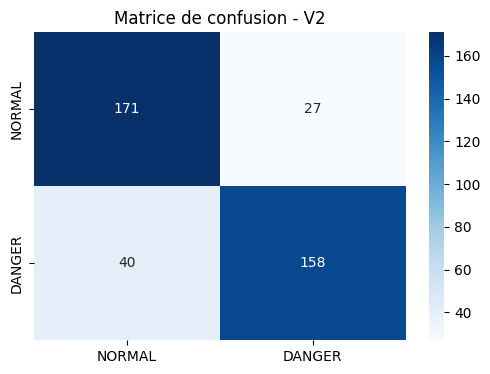


=== Comparaison ===
V1 (SESA seul)       : accuracy 78%
V2 (SESA + Violence) : accuracy 84.3%


In [10]:
y_pred_v2 = (model_v2.predict(X_test) > 0.5).astype(int)

print("=== Résultats V2 ===")
print(classification_report(y_test, y_pred_v2,
      target_names=["NORMAL", "DANGER"]))

cm = confusion_matrix(y_test, y_pred_v2)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=["NORMAL", "DANGER"],
            yticklabels=["NORMAL", "DANGER"],
            cmap="Blues")
plt.title("Matrice de confusion - V2")
plt.show()

print("\n=== Comparaison ===")
print(f"V1 (SESA seul)       : accuracy 78%")
print(f"V2 (SESA + Violence) : accuracy {max(history_v2.history['val_accuracy'])*100:.1f}%")

In [11]:
converter = tf.lite.TFLiteConverter.from_keras_model(model_v2)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model_v2 = converter.convert()

with open("audio_classifier_v2.tflite", "wb") as f:
    f.write(tflite_model_v2)

print(f"✅ TFLite V2 sauvegardé !")
print(f"📦 Taille : {len(tflite_model_v2)/1024:.1f} KB")

INFO:tensorflow:Assets written to: C:\Users\AHMEDM~1\AppData\Local\Temp\tmp6vcmpn05\assets


INFO:tensorflow:Assets written to: C:\Users\AHMEDM~1\AppData\Local\Temp\tmp6vcmpn05\assets


✅ TFLite V2 sauvegardé !
📦 Taille : 110.2 KB
